# Preisvorhersage mit einer multiplen linearen Regression

## 1. Einleitung

Dieses Notebook knüpft an die explorative Analyse und das Regressionsbaum-Notebook an und erstellt mit der multiplen linearen Regression ein zweites Vorhersagemodell. Ziel ist es erneut, den Angebotspreis eines Gebrauchtwagens anhand der Fahrzeugmerkmale zu schätzen und die zweite Forschungsfrage zu beantworten. Durch den Einsatz eines zweiten Verfahrens lässt sich zusätzlich beurteilen, wie robust die Ergebnisse gegenüber der Wahl des Modells sind.

Die multiple lineare Regression wurde gewählt, weil sie den Einfluss jedes einzelnen Merkmals als Koeffizient ausdrückt und dadurch besonders gut interpretierbar ist. Sie ergänzt den Regressionsbaum, der zwar flexible Zusammenhänge abbildet, seine Wirkung je Merkmal aber weniger transparent macht.

Ein zentraler Punkt ist der Umgang mit der starken Rechtsschiefe der Preise, die sich bereits in der explorativen Analyse und in der Bewertung des Regressionsbaums gezeigt hat. Da wenige sehr teure Fahrzeuge die Ergebnisse verzerren, wird der Preis logarithmisch transformiert, wodurch die extremen Werte gestaucht werden und die Annahmen der linearen Regression besser erfüllt sind. Als Vergleichsmaßstab dient wieder ein einfaches Baseline-Modell. Die Güte wird mit den Kennzahlen R², RMSE und MAE bewertet, durch eine Analyse der Residuen überprüft und mit einer Kreuzvalidierung abgesichert.

## 2. Setup

In [ ]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import LinearRegression
from sklearn.dummy import DummyRegressor
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from scipy import stats
import sys

# Darstellung
%matplotlib inline
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

# Pfade, eigener Bilder-Ordner für dieses Notebook
DATA_PROCESSED = Path("../data/processed/data_processed.csv")
IMG_DIR = Path("../images/modeling/regression")
IMG_DIR.mkdir(parents=True, exist_ok=True)

# Gemeinsame Bewertungsfunktionen aus src/metrics.py
sys.path.append("../src")
from metrics import kennzahlen, speichere_ergebnis, formatierte_tabelle, als_markdown

In [2]:
# Bereinigte Daten laden
df = pd.read_csv(DATA_PROCESSED)
print("Shape:", df.shape)
df.head()

Shape: (243060, 10)


,brand,model,color,registration_month,year,mileage_in_km,power_ps,transmission_type,fuel_type,price_in_euro
0,alfa-romeo,Alfa Romeo GTV,red,10,1995,160500.0,201,Manual,Petrol,1300.0
1,alfa-romeo,Alfa Romeo 164,black,2,1995,190000.0,260,Manual,Petrol,24900.0
2,alfa-romeo,Alfa Romeo Spider,black,7,1995,189500.0,150,Manual,Petrol,4900.0
3,alfa-romeo,Alfa Romeo 164,red,11,1996,96127.0,179,Manual,Petrol,17950.0
4,alfa-romeo,Alfa Romeo Spider,red,4,1996,47307.0,150,Manual,Petrol,7900.0


## 3. Merkmalsauswahl und Vorbereitung

In [3]:
# Zielgröße und Merkmale, identisch zum Regressionsbaum für die Vergleichbarkeit
ziel = "price_in_euro"
num_features = ["year", "mileage_in_km", "power_ps"]
kat_features = ["brand", "color", "transmission_type", "fuel_type"]

X = df[num_features + kat_features]
y = df[ziel]

print("Merkmale X:", X.shape, "Zielgröße y:", y.shape)

Merkmale X: (243060, 7) Zielgröße y: (243060,)


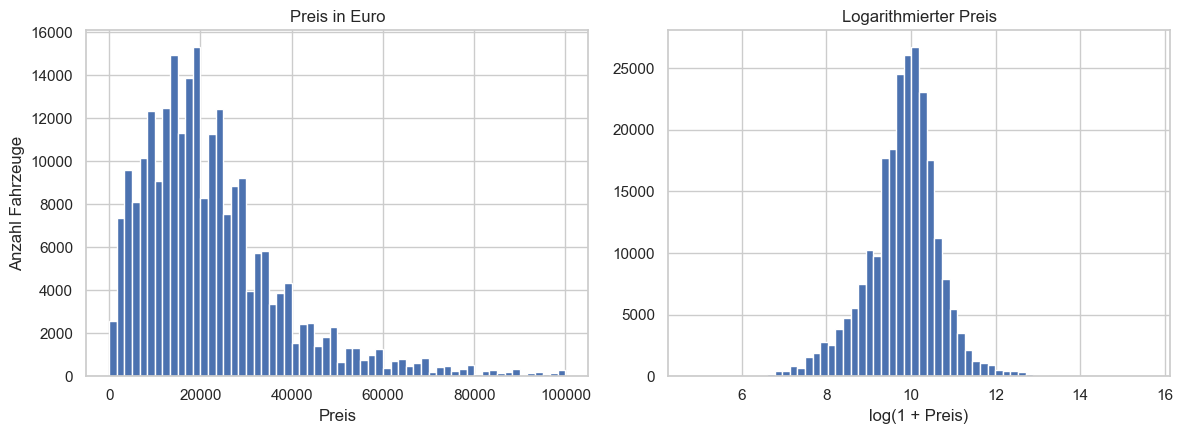

In [4]:
# Vergleich der Verteilung von Preis und logarithmiertem Preis
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].hist(y, bins=60, range=(0, 100000), color="#4C72B0", edgecolor="white")
axes[0].set_title("Preis in Euro")
axes[0].set_xlabel("Preis")
axes[0].set_ylabel("Anzahl Fahrzeuge")

axes[1].hist(np.log1p(y), bins=60, color="#4C72B0", edgecolor="white")
axes[1].set_title("Logarithmierter Preis")
axes[1].set_xlabel("log(1 + Preis)")

plt.tight_layout()
plt.savefig(IMG_DIR / "log_transformation.png", dpi=150, bbox_inches="tight")
plt.show()

Der Preis ist im Original stark rechtsschief, während der logarithmierte Preis eine annähernd symmetrische Verteilung aufweist. Die Modellierung auf der logarithmischen Skala erfüllt die Annahmen der linearen Regression daher besser und verringert den Einfluss der wenigen sehr teuren Fahrzeuge.

## 4. Train-Test-Split und Encoding

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("Training:", X_train.shape, "Test:", X_test.shape)

Training: (194448, 7) Test: (48612, 7)


In [6]:
# Vorverarbeitung: drop="first" lässt je kategorialem Merkmal
# die erste Kategorie als Referenzkategorie weg
preprocessor = ColumnTransformer(
    transformers=[
        (
            "kat",
            OneHotEncoder(drop="first", handle_unknown="ignore"),
            kat_features
        )
    ],
    remainder="passthrough"
)

# Vorverarbeitung an die Trainingsdaten anpassen
preprocessor.fit(X_train)

# Anzahl der Merkmale nach der Kodierung
anzahl_merkmale = preprocessor.get_feature_names_out().shape[0]

# Trainierten OneHotEncoder auslesen
encoder = preprocessor.named_transformers_["kat"]

# Ausgelassene Referenzkategorien bestimmen
referenz_tabelle = pd.DataFrame({
    "Merkmal": kat_features,
    "Ausgelassene Referenzkategorie": [
        kategorien[drop_index]
        for kategorien, drop_index
        in zip(encoder.categories_, encoder.drop_idx_)
    ]
})

# Gemeinsame Ausgabe
print(f"Anzahl Merkmale nach Kodierung: {anzahl_merkmale}")
print("\nAusgelassene Referenzkategorien:")

display(referenz_tabelle)

Anzahl Merkmale nach Kodierung: 73

Ausgelassene Referenzkategorien:


,Merkmal,Ausgelassene Referenzkategorie
0,brand,alfa-romeo
1,color,beige
2,transmission_type,Automatic
3,fuel_type,CNG


Die Daten wurden in 194.448 Trainings- und 48.612 Testfälle aufgeteilt. Mit drop="first" wurde je kategorialem Merkmal eine Referenzkategorie ausgeschlossen. Nach der Kodierung umfasst das Modell 73 Merkmale; die Referenzen sind in der Tabelle ausgewiesen.

## 5. Baseline

In [7]:
# Baseline, identisch zum Baum, sagt immer den mittleren Trainingspreis vorher
baseline = DummyRegressor(strategy="mean")
baseline.fit(X_train[num_features], y_train)
print("Mittlerer Trainingspreis:", round(y_train.mean(), 2), "Euro")

Mittlerer Trainingspreis: 26142.0 Euro


Das Baseline-Modell sagt unabhängig von den Merkmalen für jedes Fahrzeug den mittleren Trainingspreis von rund 26142 Euro vorher. Es ist bewusst dasselbe Vergleichsmodell wie im Regressionsbaum, sodass beide Verfahren am identischen Maßstab gemessen werden. Die multiple lineare Regression muss diesen Wert deutlich unterbieten, damit sich ihr Einsatz rechtfertigt.

## 6. Multiple lineare Regression

In [8]:
# Pipeline aus Vorverarbeitung und linearer Regression auf logarithmiertem Preis
regression = Pipeline(steps=[
    ("vorverarbeitung", preprocessor),
    ("modell", TransformedTargetRegressor(
        regressor=LinearRegression(),
        func=np.log1p,
        inverse_func=np.expm1
    ))
])

# Training ausschließlich auf den Trainingsdaten
regression.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('vorverarbeitung', ...), ('modell', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('kat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers conta

In [9]:
# Trainiertes Regressionsmodell und Merkmalsnamen aus der Pipeline holen
lin = regression.named_steps["modell"].regressor_
feature_names = regression.named_steps["vorverarbeitung"].get_feature_names_out()

# Koeffizienten sammeln und Namen aufräumen
koef = pd.Series(lin.coef_, index=feature_names)
koef.index = koef.index.str.replace("remainder__", "").str.replace("kat__", "")

# Da auf der log-Skala trainiert wurde, als prozentualer Effekt lesbar
effekt = (np.exp(koef) - 1) * 100

koef_tabelle = pd.DataFrame({
    "Koeffizient (log)": koef.round(5),
    "Effekt (%) je Einheit": effekt.round(3)
}).sort_values("Effekt (%) je Einheit", ascending=False)

koef_tabelle

,Koeffizient (log),Effekt (%) je Einheit
fuel_type_Diesel,0.13839,14.843
year,0.07163,7.426
brand_mercedes-benz,0.06222,6.420
brand_volkswagen,0.03375,3.433
brand_audi,0.01967,1.986
...,...,...
brand_renault,-0.01493,-1.482
brand_ford,-0.02614,-2.581
brand_opel,-0.05193,-5.060
transmission_type_Manual,-0.11608,-10.960


In [10]:
# Numerische Merkmale in sinnvollen Einheiten
for merkmal, einheit, faktor in [
    ("year", "pro Jahr", 1),
    ("mileage_in_km", "pro 10.000 km", 10000),
    ("power_ps", "pro 10 PS", 10),
]:
    b = koef[merkmal] * faktor
    print(f"{merkmal:16s} {einheit:16s} {(np.exp(b)-1)*100:+.1f} %")

year             pro Jahr         +7.4 %
mileage_in_km    pro 10.000 km    -2.9 %
power_ps         pro 10 PS        +4.5 %


Die multiple lineare Regression macht den Einfluss jedes Merkmals als prozentualen Effekt auf den Preis sichtbar. Ein um ein Jahr neueres Baujahr erhöht den geschätzten Preis um rund 7,4 Prozent, je zusätzliche 10.000 Kilometer sinkt er um rund 2,9 Prozent, und je zusätzliche 10 PS steigt er um rund 4,5 Prozent. Bei den kategorialen Merkmalen sind Dieselfahrzeuge gegenüber der Referenz rund 14,8 Prozent teurer und Benzinfahrzeuge rund 12,1 Prozent günstiger, ein Schaltgetriebe senkt den Preis gegenüber der Automatik um rund 11 Prozent, und Premiummarken wie Mercedes-Benz liegen über den Massenmarken. Die Richtung aller Effekte entspricht den Erwartungen und bestätigt die Ergebnisse aus der explorativen Analyse und dem Regressionsbaum.

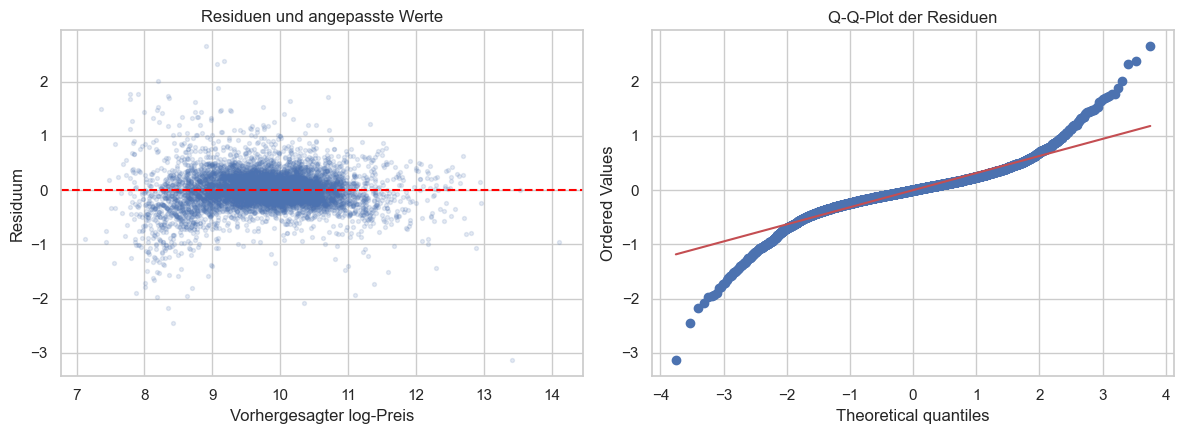

In [11]:
# Residuen auf der log-Skala, auf der das Modell trainiert wurde
log_wahr = np.log1p(y_test)
y_pred_regression = regression.predict(X_test)
log_vorhersage = np.log1p(y_pred_regression)
residuen = log_wahr - log_vorhersage

# Für eine übersichtliche Darstellung eine Stichprobe
stichprobe = pd.DataFrame(
    {"vorhersage": log_vorhersage, "residuum": residuen}
).sample(8000, random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Residuen gegen angepasste Werte
axes[0].scatter(stichprobe["vorhersage"], stichprobe["residuum"],
                alpha=0.15, s=8, color="#4C72B0")
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_title("Residuen und angepasste Werte")
axes[0].set_xlabel("Vorhergesagter log-Preis")
axes[0].set_ylabel("Residuum")

# Q-Q-Plot der Residuen
stats.probplot(stichprobe["residuum"], dist="norm", plot=axes[1])
axes[1].set_title("Q-Q-Plot der Residuen")

plt.tight_layout()
plt.savefig(IMG_DIR / "residuen.png", dpi=150, bbox_inches="tight")
plt.show()

Die Residuen streuen weitgehend gleichmäßig um die Nulllinie, sodass Linearität und konstante Fehlervarianz im mittleren Preisbereich weitgehend erfüllt sind. Der Q-Q-Plot zeigt jedoch schwerere Ränder als eine Normalverteilung, weshalb sehr günstige und sehr teure Fahrzeuge mit größeren Fehlern geschätzt werden. Die logarithmische Transformation verbessert die Modellannahmen deutlich, hebt die Abweichungen an den Extremen aber nicht vollständig auf.

## 7. Bewertung und Robustheit

In [12]:
# Vorhersagen auf den Testdaten
y_pred_baseline = baseline.predict(X_test[num_features])
y_pred_regression = regression.predict(X_test)

# Kennzahlen aus src/metrics.py, identisch für beide Modell-Notebooks
r2_b, rmse_b, mae_b = kennzahlen(y_test, y_pred_baseline)
r2_r, rmse_r, mae_r = kennzahlen(y_test, y_pred_regression)

# Ergebnisse gegenüberstellen
ergebnisse = pd.DataFrame({
    "Baseline": [r2_b, rmse_b, mae_b],
    "Lineare Regression": [r2_r, rmse_r, mae_r],
}, index=["R²", "RMSE (Euro)", "MAE (Euro)"])

ergebnisse.round(2)


,Baseline,Lineare Regression
R²,-0.00,0.60
RMSE (Euro),32112.64,20264.79
MAE (Euro),15528.79,6198.44


Die lineare Regression übertrifft die Baseline deutlich und senkt den mittleren absoluten Fehler von rund 15.529 auf rund 6.198 Euro bei einem R² von 0,60. Der Regressionsbaum war auf demselben Testfeld mit einem R² von 0,79 und einem MAE von rund 5.154 Euro etwas genauer, da er nichtlineare Zusammenhänge flexibler abbildet. Die Regression bietet dafür zwei Vorteile, nämlich die unmittelbare Interpretierbarkeit über ihre Koeffizienten und eine durch die logarithmische Skala erhöhte Robustheit gegenüber den Extrempreisen.

In [13]:
# Robustheit über Kreuzvalidierung, R² und MAE über fünf Durchläufe
kf = KFold(n_splits=5, shuffle=True, random_state=42)

r2_cv = cross_val_score(regression, X_train, y_train, cv=kf, scoring="r2")
mae_cv = -cross_val_score(regression, X_train, y_train, cv=kf, scoring="neg_mean_absolute_error")

print("R² je Durchlauf:", r2_cv.round(3))
print("R² Mittelwert:", r2_cv.mean().round(3), "Streuung:", r2_cv.std().round(3))
print()
print("MAE je Durchlauf (Euro):", mae_cv.round(0))
print("MAE Mittelwert (Euro):", round(mae_cv.mean()), "Streuung:", round(mae_cv.std()))

c:\Users\flott\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
c:\Users\flott\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


R² je Durchlauf: [0.402 0.532 0.599 0.576 0.567]
R² Mittelwert: 0.535 Streuung: 0.07

MAE je Durchlauf (Euro): [6546. 6618. 6372. 6434. 6425.]
MAE Mittelwert (Euro): 6479 Streuung: 90


### Modellvergleich

Die folgende Tabelle führt die Ergebnisse aus Notebook 02 und 03 zusammen. Sie wird
aus den in `results/` abgelegten Kennzahlen erzeugt, sodass keine Werte von Hand
übertragen werden. Voraussetzung ist, dass Notebook 02 zuvor einmal ausgeführt wurde.

In [14]:
# Ergebnis ablegen und die Vergleichstabelle aller Modelle erzeugen
speichere_ergebnis("Multiple Regression", rang=3, r2_test=r2_r, rmse_test=rmse_r,
                   mae_test=mae_r, r2_cv=r2_cv, mae_cv=mae_cv)

tabelle = formatierte_tabelle()
tabelle.to_csv("../results/modellvergleich.csv", index=False)


print(als_markdown(tabelle))
tabelle


| Modell              | R² (Test) | R² (Kreuzvalidierung) | MAE (Test) | MAE (Kreuzvalidierung) |
|---------------------|-----------|-----------------------|------------|------------------------|
| Baseline            | 0,00      | —                     | 15.529 €   | —                      |
| Regressionsbaum     | 0,79      | 0,40 ± 0,22           | 5.154 €    | 5.381 €                |
| Multiple Regression | 0,60      | 0,54 ± 0,07           | 6.198 €    | 6.479 €                |


,Modell,R² (Test),R² (Kreuzvalidierung),MAE (Test),MAE (Kreuzvalidierung)
0,Baseline,"0,00",—,15.529 €,—
1,Regressionsbaum,"0,79","0,40 ± 0,22",5.154 €,5.381 €
2,Multiple Regression,"0,60","0,54 ± 0,07",6.198 €,6.479 €


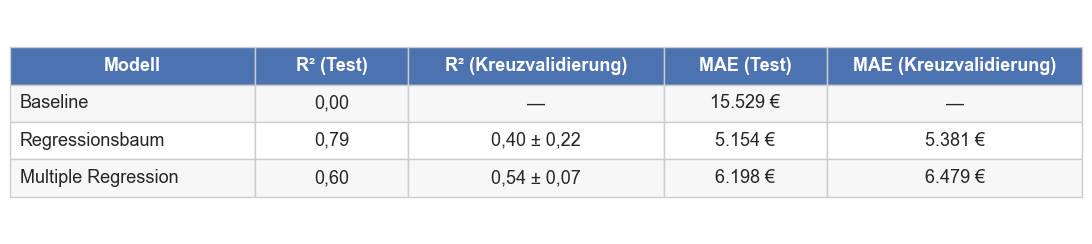

In [17]:
# Vergleichstabelle
VERGLEICH_DIR = Path("../images/modeling/regressionsbaum")
VERGLEICH_DIR.mkdir(parents=True, exist_ok=True)

fig, ax = plt.subplots(figsize=(11, 2.6))
ax.axis("off")

tab = ax.table(cellText=tabelle.values, colLabels=tabelle.columns,
               colWidths=[0.24, 0.15, 0.25, 0.16, 0.25],
               cellLoc="center", loc="center")
tab.auto_set_font_size(False)
tab.set_fontsize(13)
tab.scale(1, 2.0)

for (zeile, spalte), zelle in tab.get_celld().items():
    zelle.set_edgecolor("#cccccc")
    if zeile == 0:                                   # Kopfzeile
        zelle.set_text_props(weight="bold", color="white")
        zelle.set_facecolor("#4C72B0")
    else:
        zelle.set_facecolor("#f7f7f7" if zeile % 2 else "white")
    if spalte == 0 and zeile > 0:                    # Modellnamen linksbündig
        zelle.set_text_props(ha="left")
        zelle.PAD = 0.04

plt.tight_layout()
plt.savefig(VERGLEICH_DIR / "modellvergleich.png", dpi=200, bbox_inches="tight")
plt.show()


Die Kreuzvalidierung liefert ein R² zwischen 0,40 und 0,60, im Mittel 0,535 mit einer geringen Streuung von 0,07. Der MAE bleibt über alle fünf Durchläufe eng zwischen rund 6.372 und 6.618 Euro, im Mittel bei 6.479 Euro mit einer Streuung von nur 90 Euro. Beide Kennzahlen sind damit sehr stabil, sodass das Modell zuverlässig verallgemeinert.

## 8. Zwischenfazit


In diesem Notebook wurde mit der multiplen linearen Regression ein zweites Modell zur Preisvorhersage erstellt. Es nutzt dieselben Merkmale wie der Regressionsbaum, transformiert den Preis wegen der starken Rechtsschiefe logarithmisch und lässt bei der Kodierung je Merkmal eine Referenzkategorie weg, um Multikollinearität zu vermeiden. Der Vorteil des Verfahrens liegt in der Interpretierbarkeit, denn jeder Koeffizient beschreibt einen prozentualen Effekt auf den Preis. Ein neueres Baujahr, mehr Leistung sowie Diesel und Premiummarken erhöhen den geschätzten Preis, während eine höhere Laufleistung, ein Schaltgetriebe und Massenmarken ihn senken.

Auf dem einzelnen Testfeld erreicht die Regression ein R² von 0,60 und einen mittleren Fehler von rund 6.198 Euro und übertrifft die Baseline damit deutlich. Der Regressionsbaum war auf diesem Testfeld zwar etwas genauer, die Kreuzvalidierung zeigt jedoch, dass die Regression mit einem mittleren R² von 0,535 und einer Streuung von nur 0,07 deutlich stabiler verallgemeinert. Die Residuenanalyse bestätigt, dass die Modellannahmen im mittleren Preisbereich weitgehend erfüllt sind, an den Extremen aber schwerere Ränder auftreten. Insgesamt ergänzt die Regression den Baum, indem sie etwas an Genauigkeit einbüßt, dafür aber robuster und transparent interpretierbar ist.